In [1]:
import sys
sys.path.insert(0, '..')

from pathlib import Path
from brainrender._io import load_mesh_from_file
from myterial import orange
from rich import print
from brainglobe_atlasapi import BrainGlobeAtlas
from brainrender import Scene
import brainrender
from brainrender.actors import Points, Line
import numpy as np
from utils import slice_util
from PIL import Image
import os
import subprocess
import  vedo 
import pandas as pd
import brainglobe_heatmap as bgh
import matplotlib.pyplot as plt
import matplotlib 
from matplotlib import gridspec

import importlib
from brainglobe_heatmap import heatmaps

importlib.reload(heatmaps)
import multiprocessing
import brainglobe_heatmap.heatmaps as bgh
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
import logging
import os
from datetime import datetime


# 로그 생성
logger = logging.getLogger()

# 로그의 출력 기준 설정
logger.setLevel(logging.INFO)

# log 출력 형식
formatter = logging.Formatter('%(asctime)s[%(levelname)s]: %(message)s')

while logger.hasHandlers():
    logger.removeHandler(logger.handlers[0])
    
    
# log 출력
stream_handler = logging.StreamHandler()
stream_handler.setFormatter(formatter)
logger.addHandler(stream_handler)


In [3]:
# Get the "Blues" colormap
cmap = plt.cm.Blues

# Get the colormap colors as a list
cmap_colors = cmap(np.linspace(0, 1, cmap.N))

# Select a subset of the colormap (adjust the start value to control darkness)
start_index = int(0.2 * cmap.N)  # Start from a darker shade
new_cmap_colors = cmap_colors[start_index:]
new_cmap_colors


array([[0.81411765, 0.88392157, 0.94980392, 1.        ],
       [0.81116494, 0.88195309, 0.94881968, 1.        ],
       [0.80821223, 0.87998462, 0.94783545, 1.        ],
       [0.80525952, 0.87801615, 0.94685121, 1.        ],
       [0.80230681, 0.87604767, 0.94586697, 1.        ],
       [0.79935409, 0.8740792 , 0.94488274, 1.        ],
       [0.79640138, 0.87211073, 0.9438985 , 1.        ],
       [0.79344867, 0.87014225, 0.94291426, 1.        ],
       [0.79049596, 0.86817378, 0.94193003, 1.        ],
       [0.78754325, 0.86620531, 0.94094579, 1.        ],
       [0.78459054, 0.86423683, 0.93996155, 1.        ],
       [0.78163783, 0.86226836, 0.93897732, 1.        ],
       [0.77868512, 0.86029988, 0.93799308, 1.        ],
       [0.77524029, 0.85830065, 0.9368243 , 1.        ],
       [0.77031911, 0.85620915, 0.93510188, 1.        ],
       [0.76539792, 0.85411765, 0.93337947, 1.        ],
       [0.76047674, 0.85202614, 0.93165705, 1.        ],
       [0.75555556, 0.84993464

/tmp/ipykernel_3951764/2081270099.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Blues')


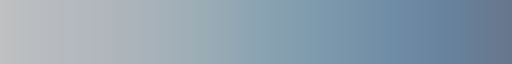

In [4]:
from matplotlib.colors import LinearSegmentedColormap

# Get the "Blues" colormap
cmap = plt.cm.get_cmap('Blues')

# Extract the color values from the colormap
colors = cmap(np.linspace(0, 1, cmap.N))

# Reduce the lightness of the colors to darken the colormap
# A simple way to darken is to reduce the RGB values
darkening_factor = 0.6  # Adjust this value to control the darkness
darkened_colors = colors * darkening_factor
darkened_colors = np.clip(darkened_colors, 0, 1) # Ensure values stay within the valid range [0, 1]

# Create a new colormap from the darkened colors
darkened_blues = LinearSegmentedColormap.from_list('darkened_blues', darkened_colors)
darkened_blues

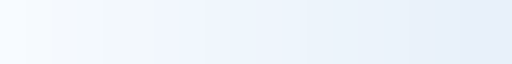

In [5]:
from matplotlib import colormaps
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
cmap_names = list(colormaps)
#print(cmap_names)

import imageio
viridis = plt.get_cmap('Blues')
tab10_r = ListedColormap(viridis(np.arange(20)))
tab10_r.colors[0][:3]
tab10_r

In [6]:
bg_atlas = BrainGlobeAtlas("allen_mouse_50um", check_latest=False)
#bg_atlas.lookup_df.acronym.values
#regions = ['root']
#obj_file_names = [ str(bg_atlas.meshfile_from_structure(region)) for region in regions ]
#combined_obj_file_name = 'output/combined.obj'
#slice_util.combine_obj_file_list(obj_file_names,combined_obj_file_name)
#root_mesh = load_mesh_from_file(combined_obj_file_name, alpha=0.1, color="black")
#bg_atlas.structures[107]

In [7]:
bg_atlas.structures['MOB']


{
    'acronym': 'MOB',
    'id': 507,
    'name': 'Main olfactory bulb',
    'structure_id_path': [997, 8, 567, 688, 695, 698, 507],
    'rgb_triplet': [154, 210, 189],
    'mesh_filename': PosixPath('/home/jhahn/.brainglobe/allen_mouse_50um_v1.2/meshes/507.obj'),
    'mesh': <meshio mesh object>
  Number of points: 5853
  Number of cells:
    triangle: 11694
  Point data: obj:vn
  Cell data: obj:group_ids
}

In [15]:
df_fold =  pd.read_csv('output/fold.csv')
df_fold.set_index("Region ID", inplace=True)

df_id_2_region_name= pd.read_csv('resources/id_name.csv')
region_id_2_region_name = {}
region_name_2_region_id = {}
region_id_2_tg_id = {}

for _i, _row in df_id_2_region_name[['TG number','Region ID','Region name']].iterrows():
    region_id_2_region_name[_row['Region ID']] = _row['Region name']
    region_name_2_region_id[_row['Region name']] = _row['Region ID']
    region_id_2_tg_id[_row['Region ID']] = _row['TG number']


df_fold = df_fold[df_fold.columns[2:]]
df_id_2_region_name


,TG number,Region ID,Region name
0,1,0,Clear Label
1,2,997,root
2,3,8,Basic cell groups and regions
3,4,567,Cerebrum
4,5,688,Cerebral cortex
...,...,...,...
1323,1324,49,intraparafloccular fissure
1324,1325,57,paramedian sulcus
1325,1326,65,parafloccular sulcus
1326,1327,624,Interpeduncular fossa


In [16]:
df_mean_cor_sag = pd.read_csv('output/df_mean_cor_sag.csv', encoding='utf-8')

In [17]:
df_mean_cor_sag

,sample_id,color,veh_exp,997,68,667,526157192,526157196,526322264,320,...,595,611,81,98,108,129,140,145,153,164
0,0644,PV,0,0.002148,0.000679,0.006124,0.017237,0.019315,0.003596,0.000938,...,0.000237,0.005452,0.001965,0.002563,0.003553,0.003217,0.074078,0.025499,0.043611,0.0
1,0644,PV-cfos,0,0.000634,0.000012,0.000500,0.000728,0.001258,0.000000,0.000021,...,0.000000,0.000239,0.000583,0.005770,0.000504,0.002744,0.006547,0.005196,0.001932,0.0
2,0644,PV/cfos fraction,0,15.324702,1.664255,7.554717,3.986538,4.300120,0.000000,1.760268,...,0.000000,51.416860,12.529551,69.242770,9.791910,24.406403,4.180795,14.731290,8.039082,NaN
3,0644,SST,0,0.005803,0.013687,0.012543,0.042722,0.044093,0.008101,0.009869,...,0.006073,0.078911,0.003139,0.007811,0.000427,0.004225,0.001340,0.004549,0.012576,0.0
4,0644,SST-PV,0,0.000335,0.000000,0.000664,0.004627,0.006537,0.002697,0.000160,...,0.000022,0.000000,0.000116,0.000021,0.000012,0.000003,0.000057,0.004574,0.002083,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,A0249,SST-PV/cfos fraction,1,40.176219,0.000000,4.930233,15.573248,0.305588,0.000000,51.698113,...,2.796053,46.706101,0.000000,0.000000,67.676699,91.911765,0.000000,25.000000,0.000000,0.0
117,A0249,SST-cfos,1,0.000795,0.001398,0.000352,0.000837,0.001671,0.000000,0.014662,...,0.000127,0.003553,0.000167,0.001225,0.000066,0.000540,0.000000,0.000000,0.000000,0.0
118,A0249,SST/cfos fraction,1,15.767347,13.215484,5.079365,8.849511,6.618758,NaN,10.668844,...,1.425834,14.097528,24.274027,53.006507,11.850168,20.276571,0.000000,0.000000,NaN,NaN
119,A0249,cfos,1,0.010702,0.002162,0.022792,0.025357,0.031216,0.000000,0.006688,...,0.012719,0.003133,0.011127,0.022714,0.018118,0.010259,0.004864,0.000598,0.000000,0.0


In [18]:
region_id_matched_atlas_list = []
id_list = []
name_list = []
num_of_pts_list = []

num_of_regions = 0
num_of_leaf_in_atlas = 0

atlas_regions_not_found_in_tg = []
atlas_regions_not_found_in_tg_and_has_values = 0
for _index, _region_name in enumerate(bg_atlas.structures):

    num_of_regions += 1
    if len(bg_atlas.get_structure_descendants(_region_name))==0:
        num_of_leaf_in_atlas += 1
    region_id = bg_atlas.structures[_region_name]['id']


    region_id_matched_atlas_list.append(region_id)

    if region_id not in region_id_2_region_name:

        if df_mean_cor_sag[region_id].sum() > 0:
            atlas_regions_not_found_in_tg_and_has_values += 1

        atlas_regions_not_found_in_tg.append(region_id)

tg_regions_not_found_in_atlas = []
tg_regions_not_found_in_atlas_and_has_value_list = []
for _i, _row in df_id_2_region_name.iterrows():

    if _row['Region ID'] in bg_atlas.structures:
        continue

    tg_regions_not_found_in_atlas.append(_i)

    if str(_row['Region ID']) in df_mean_cor_sag.columns:
        if df_mean_cor_sag[str(_row['Region ID'])].sum() > 0:
            tg_regions_not_found_in_atlas_and_has_value_list.append(_row['TG number'])


df_id_2_region_name[df_id_2_region_name['TG number'].isin(tg_regions_not_found_in_atlas)].to_csv('output/tg_regions_not_found_in_atlas.csv')
df_id_2_region_name[df_id_2_region_name['TG number'].isin(atlas_regions_not_found_in_tg)].to_csv('output/atlas_regions_not_found_in_tg.csv')

print('the number of regions in Atlas:',num_of_regions)
print('the number of regions in TG:',len(df_id_2_region_name))
print('the number of leaf regions in TG:',num_of_leaf_in_atlas)


print('the number of regions in Atlas but not in tg:',len(atlas_regions_not_found_in_tg))
print('the number of regions in Atlas but not in tg, has value:',atlas_regions_not_found_in_tg_and_has_values)
print('the number of regions in tg but not in Atlas:',len(tg_regions_not_found_in_atlas))
print('the number of regions in tg but not in Atlas, has value:',len(tg_regions_not_found_in_atlas_and_has_value_list))

df_id_2_region_name[df_id_2_region_name['TG number'].isin(tg_regions_not_found_in_atlas_and_has_value_list)].to_csv('output/tg_regions_not_found_in_atlas_and_has_value.csv')


the number of regions in Atlas: 840

the number of regions in TG: 1328

the number of leaf regions in TG: 643

the number of regions in Atlas but not in tg: 0

the number of regions in Atlas but not in tg, has value: 0

the number of regions in tg but not in Atlas: 488

the number of regions in tg but not in Atlas, has value: 17

In [19]:
with open('resources/region_id_matched_atlas_list.txt') as f:
    region_id_matched_atlas_list = f.read().splitlines()
region_id_matched_atlas_list = [int(a) for a in region_id_matched_atlas_list]
df_fold_in_leaf = df_fold[df_fold.index.isin(region_id_matched_atlas_list)]

In [20]:
df_fold

,SST/cfos fraction,SST,PV/cfos fraction,SST-PV,SST-PV/cfos fraction,SST-cfos,PV,SST-PV-cfos,cfos total,cfos,PV-cfos
Region ID,,,,,,,,,,,
997,1.316529,0.993444,1.683277,0.337594,3.180721,1.249327,0.711638,0.733963,0.997655,0.953750,1.319255
68,0.833072,1.058932,1.405757,21.963696,0.659461,0.928513,0.644635,28.055556,0.218449,0.171650,0.347103
667,0.812299,0.742329,0.974573,0.749241,0.498275,0.535804,0.829584,0.619455,1.057050,1.123133,0.959463
526157192,1.039006,0.898528,1.203470,0.066656,3.067865,0.887216,0.799514,0.173150,0.973516,1.008182,1.136371
526157196,1.260930,0.893565,1.928672,0.805139,2.446566,1.145601,0.917953,2.145390,1.011489,0.976221,1.412729
...,...,...,...,...,...,...,...,...,...,...,...
129,0.813494,0.685328,1.099775,2.669031,5.520714,0.593915,0.528693,89.375000,0.889469,0.807275,1.284834
140,0.628343,0.557250,0.343183,61.986166,0.898843,0.594826,0.324473,16.250000,0.790588,0.895059,0.692246
145,0.893599,1.177127,0.950903,1.550540,6.530757,0.278327,0.968646,11.253823,1.034613,1.226017,1.116832


In [21]:
ptest = pd.read_csv('output/ptest.csv', encoding='utf-8')

fold_up = 1.5
fold_down = 0.5
def get_dict_of_fold_change_values(_df_fold, name_2_id, _column, fold_up=1.5, fold_down=0.5):
    
    data_dict_up = {}
    data_dict_down = {}
    not_found_region_id = []
    for region_id, _row in _df_fold[[_column]].iterrows():
        #if tg_name in ['root','grey','fiber tracts','VS']:
        #    continue
        

        try:
            value = bg_atlas.structures[region_id]
        except:
            not_found_region_id.append(region_id)
            continue

        pvalue = ptest.query(f'Region_id=={region_id}')[_column+'_pvalue'].values[0]
        if pvalue > 0.05:
            continue

        if abs(_row[_column]) != np.inf:
            if _row[_column] > fold_up:
                data_dict_up[value['acronym']] = _row[_column]
            elif _row[_column] < fold_down and _row[_column] > 0:
                data_dict_down[value['acronym']] = _row[_column]
    #print(not_found_region_id)
    df_fold_with_not_found_region = _df_fold[_df_fold.index.isin(not_found_region_id)]
    #print(df_fold_with_not_found_region)
    not_found_region_id_with_no_zero_value = df_fold_with_not_found_region[df_fold_with_not_found_region.sum(axis=1) > 0].index
#    print(not_found_region_id_with_no_zero_value)
    not_found_region_id_with_no_zero_value = [str(a).lower() for a in not_found_region_id_with_no_zero_value]

    return data_dict_up, data_dict_down, not_found_region_id_with_no_zero_value

data_dict_up, data_dict_down, not_found_region_id_with_no_zero_value = get_dict_of_fold_change_values(df_fold,region_name_2_region_id,'SST-PV/cfos fraction',fold_up,fold_down)

print(len(data_dict_up),len(data_dict_down))
print(len(not_found_region_id_with_no_zero_value))




156 50

17

In [22]:
color_2_dict_up = {}
color_2_dict_down = {}
num_of_regions_with_fold = []
for c in df_fold.columns:
    
    data_dict_up, data_dict_down, not_found_region_id_with_no_zero_value = get_dict_of_fold_change_values(df_fold,region_name_2_region_id,c,fold_up,fold_down)
    color_2_dict_up[c] = data_dict_up
    color_2_dict_down[c] = data_dict_down

    color_2_up_down = {}
    #color_2_up_down['cut_method'] = c.split("_")[0]
    color_2_up_down['color'] = c
    color_2_up_down[f'Fold > {fold_up}'] = len(data_dict_up)
    color_2_up_down[f'Fold < {fold_down}'] = len(data_dict_down)
    num_of_regions_with_fold.append(color_2_up_down)
    
    logger.info(f'{c}, up {len(data_dict_up)}, down {len(data_dict_down)}, {len(not_found_region_id_with_no_zero_value)}')
    
'''
df_num_regions = pd.DataFrame(num_of_regions_with_fold)

df_num_regions.set_index(['color'], inplace=True)

_ttest_count = pd.read_csv('resources/ttest_count.csv', encoding='utf-8')
_ttest_count.set_index(['color'], inplace=True)

df_num_regions = pd.concat([_ttest_count,df_num_regions], axis=1)
df_num_regions.to_csv('output/sig_regions.csv')
'''

2025-05-08 00:37:08,193[INFO]: SST/cfos fraction, up 91, down 24, 17
2025-05-08 00:37:10,654[INFO]: SST, up 11, down 3, 17
2025-05-08 00:37:13,162[INFO]: PV/cfos fraction, up 77, down 76, 17
2025-05-08 00:37:15,686[INFO]: SST-PV, up 12, down 1, 17
2025-05-08 00:37:18,166[INFO]: SST-PV/cfos fraction, up 156, down 50, 17
2025-05-08 00:37:20,636[INFO]: SST-cfos, up 76, down 1, 17
2025-05-08 00:37:23,127[INFO]: PV, up 6, down 23, 17
2025-05-08 00:37:25,652[INFO]: SST-PV-cfos, up 84, down 0, 17
2025-05-08 00:37:28,148[INFO]: cfos total, up 93, down 1, 17
2025-05-08 00:37:30,668[INFO]: cfos, up 89, down 3, 17
2025-05-08 00:37:33,184[INFO]: PV-cfos, up 30, down 2, 17



"\ndf_num_regions = pd.DataFrame(num_of_regions_with_fold)\n\ndf_num_regions.set_index(['color'], 
inplace=True)\n\n_ttest_count = pd.read_csv('resources/ttest_count.csv', 
encoding='utf-8')\n_ttest_count.set_index(['color'], inplace=True)\n\ndf_num_regions = 
pd.concat([_ttest_count,df_num_regions], axis=1)\ndf_num_regions.to_csv('output/sig_regions.csv')\n"

In [24]:
def gen_brain_heatmap(ptest,color_code, fold_up, fold_down,color_2_dict_up,color_2_dict_down):
    

    try:
        plt.clf()
    except:
        pass
    # Create a figure with 6 subplots and plot the scenes

    if len(color_2_dict_up[color_code]) == 0 and len(color_2_dict_down[color_code])==0:
        return
    fig = plt.figure(figsize=(25, 10))
    #fig, axs = plt.subplots(2,7, figsize=(30, 10))
    fig.suptitle(f'{color_code}', fontsize=20)
    spec = gridspec.GridSpec(ncols=21, nrows=9, width_ratios=[1]*20 + [0.05], height_ratios = [1,1,1,0.2,1,1,1,0.2,0.5], wspace=0.001,
                            hspace=0.6)


    ax_row_index = 0
    ax_col_index = 0
    spec_index = 0
    #for subtitle, color, data_dict in [(f'Fold > {fold_up}','Blues',color_2_dict_up[color_code]),(f'Fold < {fold_down}',"Reds_r",color_2_dict_down[color_code])]:
    for subtitle, color, data_dict in [(f'Fold > {fold_up}',darkened_blues,color_2_dict_up[color_code]),(f'Fold < {fold_down}',"Reds_r",color_2_dict_down[color_code])]:
        
        #logger.info(f'{subtitle},{color_code},{len(data_dict)}')
        print(f'{subtitle},{color_code},{len(data_dict)}')
        if len(data_dict) == 0:
            continue
        
        #ax_col_index = 0
        #ax = fig.add_subplot(spec[ax_row_index:ax_row_index+3,ax_col_index])
        #ax.set_axis_off()
        #ax.text(0.5, 0.5,f'{subtitle}',  fontsize = 20)
        
        _max = np.max(list(data_dict.values()))
        _min = np.min(list(data_dict.values()))
        
        
        # AP Frontal 12000
        # LR saggital 11400
        # DV horizontal 7000
        for _i, (cut, min_dist, max_dist, gap) in enumerate([('frontal',2000,12000,500),('sagittal',6000,12000,250),('horizontal',2000,7000,250)]):

            ax_col_index = 0
            
            #ax = fig.add_subplot(spec[ax_row_index,ax_col_index])        
            #ax.set_axis_off()
            #ax.text(0.5, 0.5,f'{cut}',  fontsize = 20)
            
            #distance_list = list(range(7500, 10500, 500))
            distance_list = list(range(min_dist, max_dist, gap))
            
            #logger.info(f'{cut},{distance_list}')
            print(f'{cut},{distance_list}')

            for distance in distance_list[:20]:
            #for distance in distance_list[:1]:
                

                scene = bgh.Heatmap(
                    data_dict,
                    position=distance,
                    orientation=cut,
                    thickness=1,
                    format="3D",
                    cmap= color,
                    vmin= _min,
                    vmax= _max,
                    label_regions=False,
                    interactive = False
                )

                #ax = axs[ax_row_index,ax_col_index]
                ax = fig.add_subplot(spec[ax_row_index, ax_col_index])
                
                #if ax_col_index == 19:
                #    scene.plot_subplot(fig=fig, ax=ax, show_cbar=True, hide_axes=True)
                #else:
                scene.plot_subplot(fig=fig, ax=ax, show_cbar=False, hide_axes=True)
                ax.set_title(f'{distance} \u03BCm', fontsize=5)
                ax_col_index += 1
            
            
            if _i == 0:
                ax = fig.add_subplot(spec[ax_row_index:ax_row_index+3, ax_col_index])
                norm = matplotlib.colors.Normalize(vmin=_min, vmax=_max)
                #divider = make_axes_locatable(ax)
                #cax = divider.append_axes("left", size="5%", pad=0.05)
                cbar = fig.colorbar(
                    matplotlib.cm.ScalarMappable(norm=norm, cmap=color), cax=ax,fraction=0.046, pad=0.04
                )
                for t in cbar.ax.get_yticklabels():
                    t.set_fontsize(5)
                cbar.set_label('Fold \u0394\n(EXP/VEH)', fontsize=5)
            ax_row_index += 1
       

        

        
        ax = fig.add_subplot(spec[ax_row_index, :])
        ax.set_axis_off()
        ax.axhline(color='k', linestyle='--', linewidth=2 )
        ax_row_index += 1

    ax_col_index = 0
    ax = fig.add_subplot(spec[ax_row_index,:])
    ax.set_axis_off()
    ax.text(0, 0.1, f'Blue color: Fold \u0394 (VEH/EXP) > {fold_up},  {len(color_2_dict_up[color_code])} regions visualized\nRed color: Fold \u0394 (VEH/EXP) < {fold_down},  {len(color_2_dict_down[color_code])} regions visualized\nEach three rows is with frontal(Rostal \u2192 Caudal), saggital, horizontal view, respectively\n',  fontsize = 8)
    plt.tight_layout()
    #plt.show()
    fig.savefig(f'output/heatmap_{color_code.replace("/","_")}.png', dpi=600, bbox_inches='tight', pad_inches=1)

ptest_list = []
color_code_list = []
fold_up_list= []
fold_down_list= []
color_2_dict_up_list= []
color_2_dict_down_list= []
for color_code in df_fold.columns:
    ptest_list.append(ptest)
    color_code_list.append(color_code)
    fold_up_list.append(fold_up)
    fold_down_list.append(fold_down)
    color_2_dict_up_list.append(color_2_dict_up)
    color_2_dict_down_list.append(color_2_dict_down)

print(f'the number of jobs:{len(color_code_list)}')
with multiprocessing.Pool() as pool: # Use a pool of 4 processes
    pool.starmap(gen_brain_heatmap, zip(ptest_list,color_code_list,fold_up_list,fold_down_list,color_2_dict_up_list,color_2_dict_down_list))


the number of jobs:11

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
